In [17]:
import os
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from collections import Counter



In [18]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler, ConcatDataset
from torchvision import transforms, models, datasets
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)



In [19]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [20]:
#Importing the dataset from kaggle
import kagglehub
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")
print("Path to dataset files:", path)
DATA_DIR  = os.path.join(path, 'chest_xray')
TRAIN_DIR = os.path.join(DATA_DIR, 'train')
VAL_DIR   = os.path.join(DATA_DIR, 'val')
TEST_DIR  = os.path.join(DATA_DIR, 'test')

print("\n--- Image Counts ---")
for split, directory in [('Train', TRAIN_DIR), ('Val', VAL_DIR), ('Test', TEST_DIR)]:
    for cls in ['NORMAL', 'PNEUMONIA']:
        count = len(os.listdir(os.path.join(directory, cls)))
        print(f'{split:6} | {cls:10}: {count}')


Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Path to dataset files: /kaggle/input/chest-xray-pneumonia

--- Image Counts ---
Train  | NORMAL    : 1341
Train  | PNEUMONIA : 3875
Val    | NORMAL    : 8
Val    | PNEUMONIA : 8
Test   | NORMAL    : 234
Test   | PNEUMONIA : 390


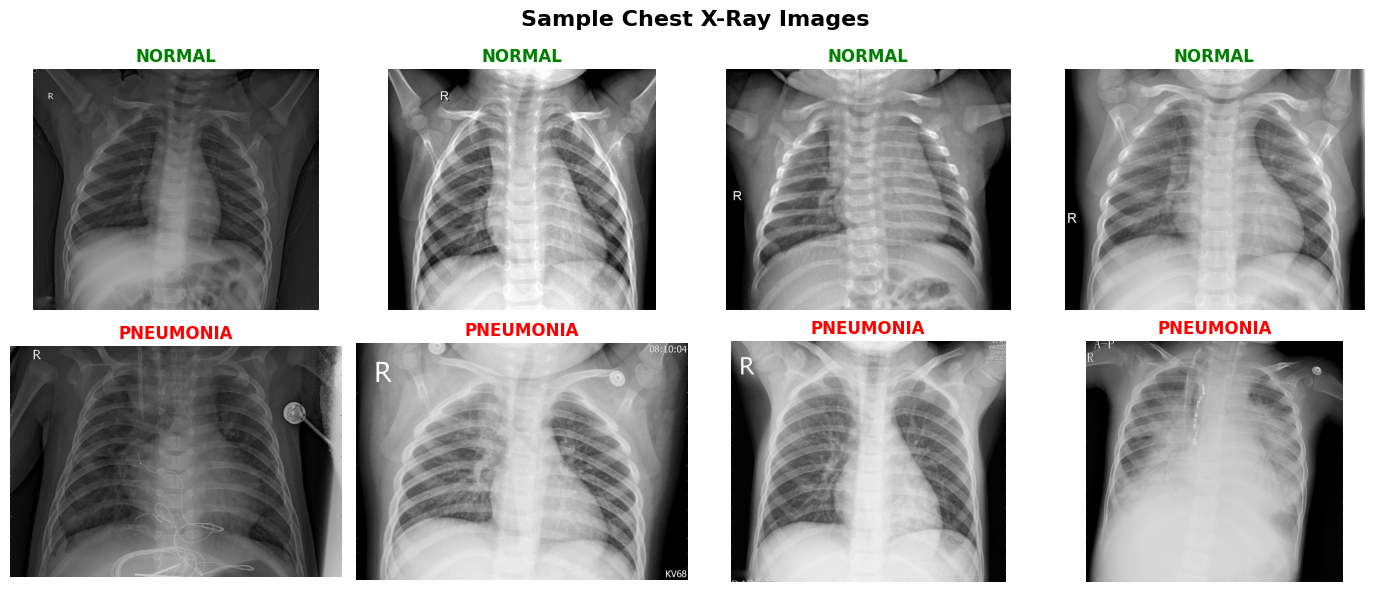

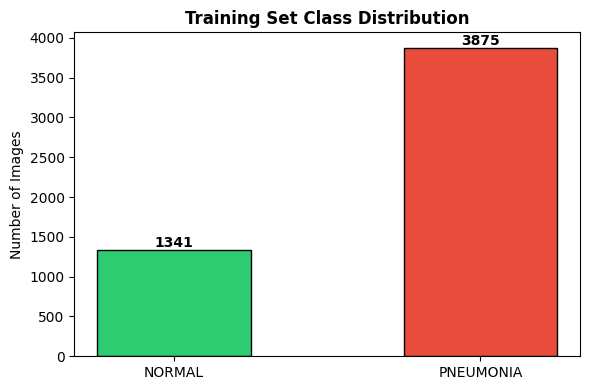

In [21]:
#Exploratory data analysis
def show_sample_images(data_dir, samples_per_class=4):
    """Show sample images from each class side by side."""
    fig, axes = plt.subplots(2, samples_per_class, figsize=(14, 6))
    fig.suptitle('Sample Chest X-Ray Images', fontsize=16, fontweight='bold')

    for row, cls in enumerate(['NORMAL', 'PNEUMONIA']):
        cls_path = os.path.join(data_dir, cls)
        images   = os.listdir(cls_path)[:samples_per_class]

        for col, img_name in enumerate(images):
            img = Image.open(os.path.join(cls_path, img_name)).convert('RGB')
            axes[row][col].imshow(img, cmap='gray')
            color = 'green' if cls == 'NORMAL' else 'red'
            axes[row][col].set_title(cls, color=color, fontweight='bold')
            axes[row][col].axis('off')

    plt.tight_layout()
    plt.savefig('sample_images.png', dpi=150, bbox_inches='tight')
    plt.show()


def plot_class_distribution(data_dir, title='Class Distribution'):
    """Bar chart of class counts."""
    counts = {
        cls: len(os.listdir(os.path.join(data_dir, cls)))
        for cls in ['NORMAL', 'PNEUMONIA']
    }

    plt.figure(figsize=(6, 4))
    bars = plt.bar(counts.keys(), counts.values(),
                   color=['#2ecc71', '#e74c3c'], edgecolor='black', width=0.5)
    plt.title(title, fontweight='bold')
    plt.ylabel('Number of Images')
    for bar, (k, v) in zip(bars, counts.items()):
        plt.text(bar.get_x() + bar.get_width() / 2, v + 30,
                 str(v), ha='center', fontweight='bold')

    plt.tight_layout()
    plt.savefig('class_distribution.png', dpi=150)
    plt.show()

show_sample_images(TRAIN_DIR)
plot_class_distribution(TRAIN_DIR, title='Training Set Class Distribution')

In [22]:
#Transformations and Data Augmentation
IMG_SIZE=224
BATCH_SIZE=32
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

train_transforms=transforms.Compose([
    transforms.Resize((IMG_SIZE+20,IMG_SIZE+20)),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD)
])

eval_transforms=transforms.Compose([
    transforms.Resize((IMG_SIZE,IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD)
])

In [23]:
raw_train=datasets.ImageFolder(TRAIN_DIR, transform=train_transforms)
raw_val=datasets.ImageFolder(VAL_DIR, transform=eval_transforms)
test_dataset=datasets.ImageFolder(TEST_DIR, transform=eval_transforms)
print('classes:', raw_train.classes)

#concat the train and test data
full_dataset=ConcatDataset([raw_train, raw_val])
print(f"Combined Dataset Size: {len(full_dataset)}")

# 90 and 10 percent data split b/w train and validation
val_size=int(0.1*len(full_dataset))
train_size=len(full_dataset)-val_size
train_dataset, val_dataset=torch.utils.data.random_split(full_dataset, [train_size, val_size], generator=torch.Generator().manual_seed(42))
print(f"Train Dataset Size: {len(train_dataset)}")
print(f"Validation Dataset Size: {len(val_dataset)}")
print(f"Test Dataset Size:{len(test_dataset)}")



classes: ['NORMAL', 'PNEUMONIA']
Combined Dataset Size: 5232
Train Dataset Size: 4709
Validation Dataset Size: 523
Test Dataset Size:624


In [24]:
#Handling the class imbalance of normal vs pnuemonia  b/w training and test images in dataset for better accuracy and training
all_labels = [raw_train.targets[i] for i in range(len(raw_train))] + \
             [raw_val.targets[i]   for i in range(len(raw_val))]

class_counts = Counter(all_labels)
print('Class counts:', class_counts)

# Weight per class = inverse frequency
class_weights = {cls: 1.0 / count for cls, count in class_counts.items()}

# Weight per SAMPLE (each sample gets its class's weight)
# We need the labels of only the TRAINING subset
train_indices = train_dataset.indices
train_labels  = [all_labels[i] for i in train_indices]
sample_weights = [class_weights[label] for label in train_labels]
sample_weights = torch.DoubleTensor(sample_weights)

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True  # allow resampling the same image
)

# DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=sampler,      # balanced sampling
    num_workers=2,        # parallel data loading
    pin_memory=True       # faster CPU to GPU transfer
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    num_workers=2,
    pin_memory=True
)

print('DataLoaders created ✅')

Class counts: Counter({1: 3883, 0: 1349})
DataLoaders created ✅


In [25]:
def build_model(num_classes=2, unfreeze_blocks=2):

    # Load pretrained model
    model = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)

    for param in model.parameters():
        param.requires_grad = False

    blocks = list(model.features.children())
    print(f'Total feature blocks: {len(blocks)}')
    print(f'Unfreezing last {unfreeze_blocks} blocks for fine-tuning')

    for block in blocks[-unfreeze_blocks:]:
        for param in block.parameters():
            param.requires_grad = True

    in_features = model.classifier.in_features  # 1024
    print(f'Classifier input features: {in_features}')

    model.classifier = nn.Sequential(
        nn.Linear(in_features, 512),
        nn.BatchNorm1d(512),
        nn.ReLU(inplace=True),
        nn.Dropout(p=0.4),
        nn.Linear(512, 128),
        nn.ReLU(inplace=True),
        nn.Dropout(p=0.3),
        nn.Linear(128, num_classes)
    )

    return model

# Build and move to device
model = build_model(num_classes=2, unfreeze_blocks=2)
model = model.to(device)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\nTotal params:     {total_params:,}')
print(f'Trainable params: {trainable_params:,}  ({100*trainable_params/total_params:.1f}%)')

Total feature blocks: 12
Unfreezing last 2 blocks for fine-tuning
Classifier input features: 1024

Total params:     7,545,602
Trainable params: 2,751,874  (36.5%)


In [26]:
NUM_EPOCHS=20
raw_weights=torch.tensor(
    [1.0/class_counts[i] for i in range(2)],
    dtype=torch.float
)
raw_weights=raw_weights/raw_weights.sum()
optimizer=optim.AdamW([
    {'params':model.features.parameters(), 'lr':1e-5},
    {'params':model.classifier.parameters(), 'lr':1e-3},
],weight_decay=1e-4)

scheduler=optim.lr_scheduler.CosineAnnealingLR(
    optimizer,T_max=NUM_EPOCHS,eta_min=1e-6
)
print(f"Class weights:NORMAL={raw_weights[0]:.4f},PNEUMONIA={raw_weights[1]:.4f}")
criterion=nn.CrossEntropyLoss(weight=raw_weights.to(device))

Class weights:NORMAL=0.7422,PNEUMONIA=0.2578


In [35]:
#For each batch:
  #1. Move images & labels to device (GPU)
  #2. optimizer.zero_grad()        clear old gradients (CRITICAL — PyTorch accumulates)
  #3. outputs = model(images)      forward pass
  #4. loss = criterion(outputs, labels)   compute loss
  #5. loss.backward()              backprop: compute gradients
  #6. optimizer.step()             update weights using gradients
  #7. Track running loss & accuracy
def train_one_epoch(model,loader,criterion,optimizer,device):
    model.train()
    running_loss=0
    correct=0
    total=0

    for images, labels in loader:
      images=images.to(device)
      labels=labels.to(device)

      #forward pass
      optimizer.zero_grad()
      outputs=model(images)
      loss=criterion(outputs, labels)

      #backward pass
      loss.backward()
      optimizer.step()

      running_loss+=loss.item()*images.size(0)
      _,predicted= torch.max(outputs, dim=1)
      correct+=(predicted==labels).sum().item()
      total+=labels.size(0)

      avg_loss=running_loss/total
      accuracy=correct/total
      return avg_loss, accuracy

def validate(model,loader, criterion, device):
  model.eval()
  running_loss=0
  correct=0
  loss=0
  total=0

  for images, labels in loader:
    images=images.to(device)
    labels=labels.to(device)

    outputs= model(images)
    loss=criterion(outputs, labels)

    running_loss+=loss.item()*images.size(0)
    _,predicted= torch.max(outputs, dim=1)
    correct+=(predicted==labels).sum().item()
    total+=labels.size(0)

  return running_loss/total , correct/total



In [36]:
# Storage for tracking
history = {
    'train_loss': [], 'val_loss': [],
    'train_acc':  [], 'val_acc':  []
}

best_val_loss    = float('inf')      # track best validation loss
best_model_wts   = copy.deepcopy(model.state_dict())
patience         = 5                 # stop after 5 epochs if no improvement
patience_counter = 0

#Starting Training
print("Starting training...\n")
print(f"{'Epoch':>6} | {'Train Loss':>10} | {'Train Acc':>9} | {'Val Loss':>8} | {'Val Acc':>7}")
print("-" * 60)

for epoch in range(1, NUM_EPOCHS + 1):

    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)

    val_loss, val_acc = validate(model, val_loader, criterion, device)

    scheduler.step()

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    print(f'{epoch:>6} | {train_loss:>10.4f} | {train_acc:>8.4f}  | {val_loss:>8.4f} | {val_acc:>7.4f}', end='')

    if val_loss < best_val_loss:
        best_val_loss  = val_loss
        best_model_wts = copy.deepcopy(model.state_dict())
        torch.save(model.state_dict(), 'best_model.pth')
        patience_counter = 0
        print('  ← best ✅')
    else:
        patience_counter += 1
        print(f'  (patience: {patience_counter}/{patience})')
        if patience_counter >= patience:
            print(f'\n⏹  Early stopping triggered at epoch {epoch}')
            break

# Restore best weights
model.load_state_dict(best_model_wts)
print('\nTraining complete. Best model loaded ✅')

Starting training...

 Epoch | Train Loss | Train Acc | Val Loss | Val Acc
------------------------------------------------------------
     1 |     0.2788 |   0.8438  |   0.3380 |  0.8394  ← best ✅
     2 |     0.3108 |   0.7812  |   0.3249 |  0.8738  ← best ✅
     3 |     0.1797 |   0.8750  |   0.3205 |  0.8815  ← best ✅
     4 |     0.1448 |   0.9375  |   0.3330 |  0.8738  (patience: 1/5)
     5 |     0.2484 |   0.8750  |   0.3065 |  0.8604  ← best ✅
     6 |     0.3487 |   0.7188  |   0.3127 |  0.8566  (patience: 1/5)
     7 |     0.1340 |   0.9375  |   0.3083 |  0.8681  (patience: 2/5)
     8 |     0.1043 |   0.9688  |   0.3102 |  0.8642  (patience: 3/5)
     9 |     0.1106 |   0.9688  |   0.3004 |  0.8719  ← best ✅
    10 |     0.1721 |   0.9688  |   0.2676 |  0.9006  ← best ✅
    11 |     0.2741 |   0.9062  |   0.2768 |  0.8719  (patience: 1/5)
    12 |     0.1937 |   0.8750  |   0.2837 |  0.8757  (patience: 2/5)
    13 |     0.2321 |   0.9062  |   0.2512 |  0.8776  ← best ✅
   

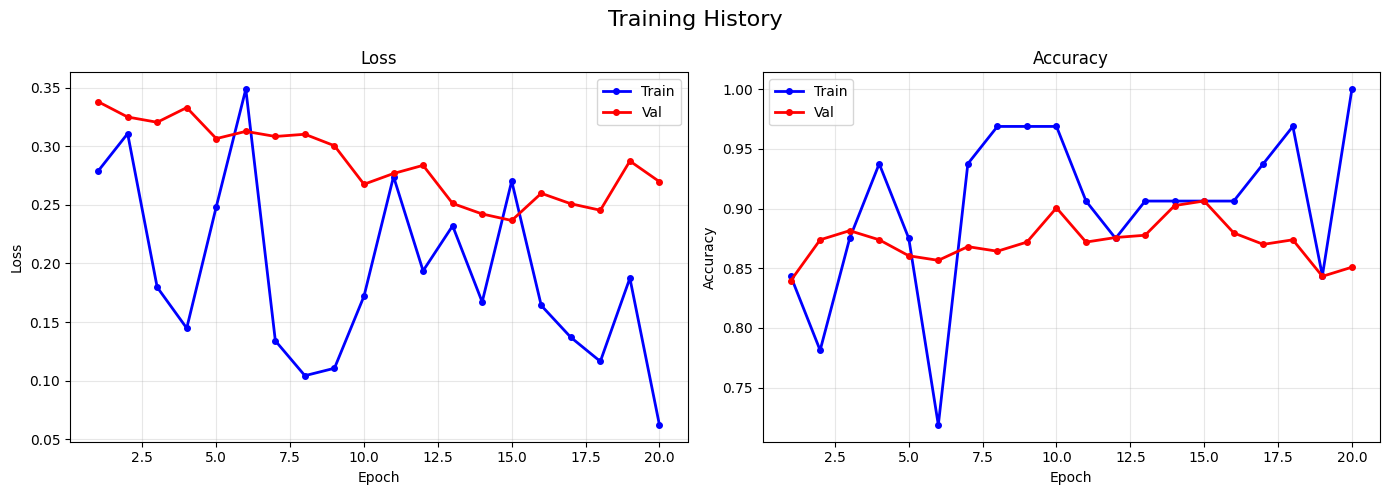

In [46]:
 def plot_training_curves(history):
    epochs = range(1, len(history['train_loss']) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Training History', fontsize=16)

    # Loss plot
    ax1.plot(epochs, history['train_loss'], 'b-o', label='Train', markersize=4, linewidth=2)
    ax1.plot(epochs, history['val_loss'],   'r-o', label='Val', markersize=4, linewidth=2)
    ax1.set_title('Loss'); ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
    ax1.legend(); ax1.grid(alpha=0.3)

    # Accuracy plot
    ax2.plot(epochs, history['train_acc'], 'b-o', label='Train', markersize=4, linewidth=2)
    ax2.plot(epochs, history['val_acc'],   'r-o', label='Val',   markersize=4, linewidth=2)
    ax2.set_title('Accuracy'); ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
    ax2.legend(); ax2.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_training_curves(history)

In [47]:
#Evaluation metrics
@torch.no_grad()
def get_all_predictions(model, loader, device):
    """Get all predictions and probabilities for the full dataset."""
    model.eval()
    all_preds  = []
    all_labels = []
    all_probs  = []

    for images, labels in loader:
        images = images.to(device)
        outputs = model(images)

        # Softmax → probabilities
        probs = torch.softmax(outputs, dim=1)
        pneumonia_prob = probs[:, 1]

        _, preds = torch.max(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(pneumonia_prob.cpu().numpy())

    return (
        np.array(all_preds),
        np.array(all_labels),
        np.array(all_probs)
    )


# Run evaluation
preds, labels, probs = get_all_predictions(model, test_loader, device)
class_names = test_dataset.classes  # ['NORMAL', 'PNEUMONIA']

print("=" * 55)
print("          TEST SET RESULTS")
print("=" * 55)
print(classification_report(labels, preds, target_names=class_names, digits=4))
print(f"ROC-AUC Score: {roc_auc_score(labels, probs):.4f}")

         TEST SET RESULTS
              precision    recall  f1-score   support

      NORMAL     0.7322    0.9231    0.8166       234
   PNEUMONIA     0.9453    0.7974    0.8651       390

    accuracy                         0.8446       624
   macro avg     0.8387    0.8603    0.8409       624
weighted avg     0.8654    0.8446    0.8469       624

ROC-AUC Score: 0.9301


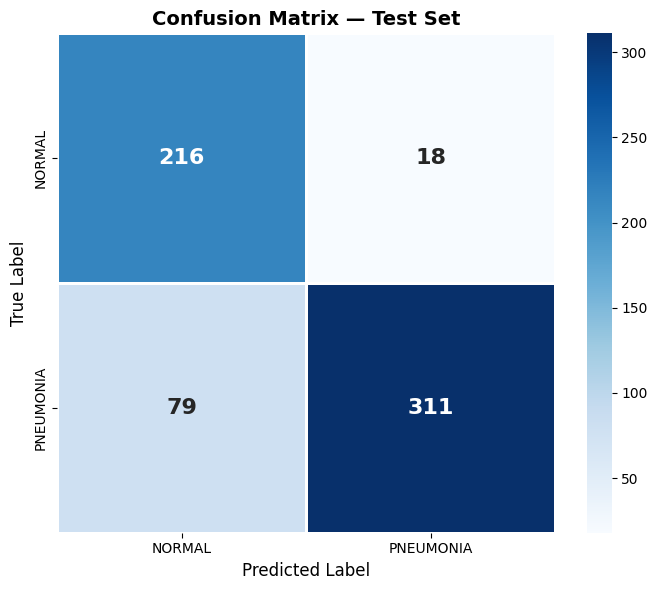

True Negatives  (Correct NORMAL):     216
False Positives (Wrong PNEUMONIA):     18
False Negatives (Missed PNEUMONIA):    79
True Positives  (Correct PNEUMONIA):   311


In [48]:
def plot_confusion_matrix(labels, preds, class_names):
    cm = confusion_matrix(labels, preds)

    plt.figure(figsize=(7, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=class_names,
        yticklabels=class_names,
        linewidths=1,
        linecolor='white',
        annot_kws={'size': 16, 'weight': 'bold'}
    )
    plt.title('Confusion Matrix — Test Set', fontweight='bold', fontsize=14)
    plt.ylabel('True Label',      fontsize=12)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.tight_layout()
    plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Print what each cell means
    tn, fp, fn, tp = cm.ravel()
    print(f"True Negatives  (Correct NORMAL):     {tn}")
    print(f"False Positives (Wrong PNEUMONIA):     {fp}")
    print(f"False Negatives (Missed PNEUMONIA):    {fn}")
    print(f"True Positives  (Correct PNEUMONIA):   {tp}")


plot_confusion_matrix(labels, preds, class_names)

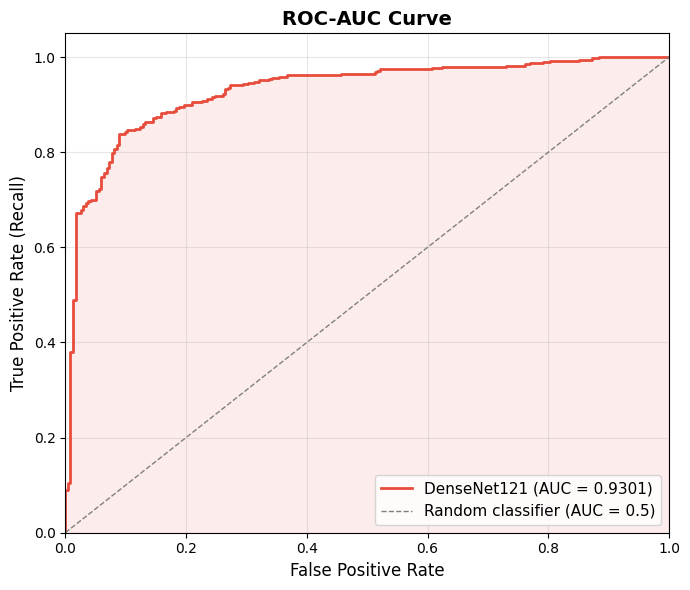

In [49]:
def plot_roc_curve(labels, probs):
    fpr, tpr, thresholds = roc_curve(labels, probs)
    auc_score = roc_auc_score(labels, probs)

    plt.figure(figsize=(7, 6))
    plt.plot(fpr, tpr, color='#e74c3c', lw=2,
             label=f'DenseNet121 (AUC = {auc_score:.4f})')
    plt.plot([0, 1], [0, 1], color='gray', linestyle='--',
             lw=1, label='Random classifier (AUC = 0.5)')
    plt.fill_between(fpr, tpr, alpha=0.1, color='#e74c3c')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate (Recall)', fontsize=12)
    plt.title('ROC-AUC Curve', fontweight='bold', fontsize=14)
    plt.legend(loc='lower right', fontsize=11)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig('roc_curve.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_roc_curve(labels, probs)

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1867: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


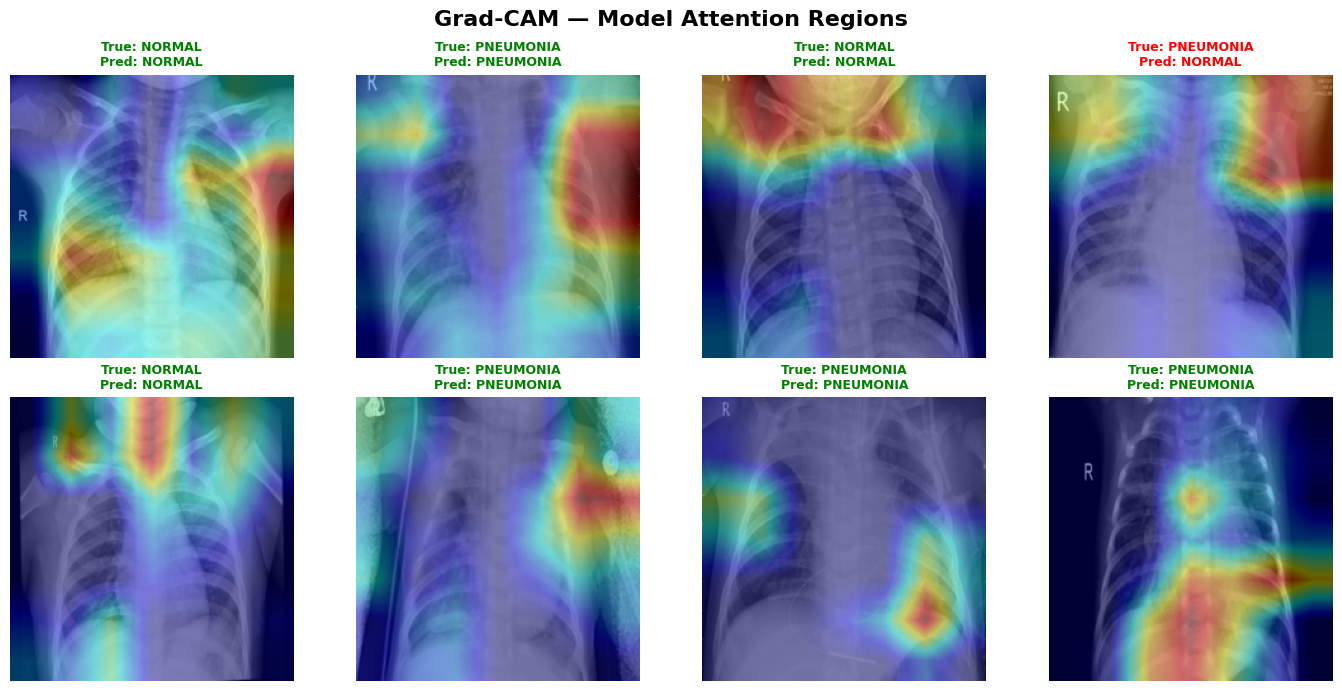

In [50]:
import cv2

class GradCAM:
    def __init__(self, model, target_layer):
        self.model       = model
        self.gradients   = None
        self.activations = None
        target_layer.register_forward_hook(self._save_activations)
        target_layer.register_backward_hook(self._save_gradients)

    def _save_activations(self, module, input, output):
        """Called during forward pass — save feature maps."""
        self.activations = output.detach()

    def _save_gradients(self, module, grad_input, grad_output):
        """Called during backward pass — save gradients."""
        self.gradients = grad_output[0].detach()

    def generate_heatmap(self, image_tensor, class_idx=None):
        """
        Generate Grad-CAM heatmap for given image.
        class_idx: which class to explain (None = use predicted class)
        """
        self.model.eval()

        output = self.model(image_tensor)

        if class_idx is None:
            class_idx = output.argmax(dim=1).item()

        self.model.zero_grad()
        output[0, class_idx].backward()
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * self.activations).sum(dim=1, keepdim=True)
        cam = torch.relu(cam)  # only positive activations matter
        cam = cam.squeeze().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam, class_idx


def show_gradcam_grid(model, dataset, device, n_samples=4):
    """Show Grad-CAM overlays for random test samples."""
    target_layer = model.features.denseblock4.denselayer16.conv2
    gradcam = GradCAM(model, target_layer)
    indices = np.random.choice(len(dataset), n_samples * 2, replace=False)
    fig, axes = plt.subplots(2, n_samples, figsize=(14, 7))
    fig.suptitle('Grad-CAM — Model Attention Regions', fontsize=16, fontweight='bold')

    for i, idx in enumerate(indices):
        row, col = divmod(i, n_samples)
        if row >= 2: break

        img_tensor, true_label = dataset[idx]
        input_batch = img_tensor.unsqueeze(0).to(device)

        cam, pred_idx = gradcam.generate_heatmap(input_batch)

        cam_resized = cv2.resize(cam, (IMG_SIZE, IMG_SIZE))
        heatmap = cv2.applyColorMap(np.uint8(255 * cam_resized), cv2.COLORMAP_JET)
        original = img_tensor.permute(1, 2, 0).numpy()
        original = original * np.array(STD) + np.array(MEAN)
        original = np.clip(original, 0, 1)
        original_uint8 = np.uint8(255 * original)
        overlay = cv2.addWeighted(original_uint8, 0.6, heatmap, 0.4, 0)
        overlay_rgb = cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB)

        axes[row][col].imshow(overlay_rgb)
        true_name = dataset.classes[true_label]
        pred_name = dataset.classes[pred_idx]
        color = 'green' if true_label == pred_idx else 'red'
        axes[row][col].set_title(
            f'True: {true_name}\nPred: {pred_name}',
            color=color, fontsize=9, fontweight='bold'
        )
        axes[row][col].axis('off')

    plt.tight_layout()
    plt.savefig('gradcam.png', dpi=150, bbox_inches='tight')
    plt.show()


show_gradcam_grid(model, test_dataset, device)

In [51]:
#predict single image
@torch.no_grad()
def predict_image(image_path, model, device):
    """
    Predict class for a single X-ray image.
    Returns (class_name, confidence_percent)
    """
    class_names = ['NORMAL', 'PNEUMONIA']

    img = Image.open("kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray/test/PNEUMONIA/person100_bacteria_475.jpeg").convert('RGB')
    tensor = eval_transforms(img).unsqueeze(0).to(device)
    # Predict
    model.eval()
    output = model(tensor)
    probs  = torch.softmax(output, dim=1)[0]
    pred   = probs.argmax().item()

    confidence = probs[pred].item() * 100

    # Display
    plt.figure(figsize=(5, 5))
    plt.imshow(img, cmap='gray')
    color = 'green' if pred == 0 else 'red'
    plt.title(
        f'Prediction: {class_names[pred]}\nConfidence: {confidence:.1f}%',
        color=color, fontweight='bold', fontsize=13
    )
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    return class_names[pred], confidence
